# Iris Flower Classification

## Objectives 
The objective of this project is to build a machine learning classification model that predicts the species of an iris flower based on its physical measurements.

## Technologies used 
- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Scikit-learn

## Dataset 
The Iris dataset is a built-in dataset available in the scikit-learn library. It contains 150samples of iris flowers belonging to three species:
- Iris Setosa
- Iris Versicolor
- Iris Virginica

In [2]:
import pandas as pd 
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

import warnings
warnings.filterwarnings("ignore")

In [3]:
iris = load_iris()

df = pd.DataFrame(iris.data, columns= iris.feature_names)

df["Species"]=iris.target

df["Species"] = df["Species"].map({
    0: "Sentosa",
    1: "Versicolor",
    2: "Virginica"
})

df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),Species
0,5.1,3.5,1.4,0.2,Sentosa
1,4.9,3.0,1.4,0.2,Sentosa
2,4.7,3.2,1.3,0.2,Sentosa
3,4.6,3.1,1.5,0.2,Sentosa
4,5.0,3.6,1.4,0.2,Sentosa


## Exploratory Data Analysis (EDA)

In this section, we will examine the dataset structure, check for missing values, analyze data types, and compute descriptive statistics before building machine learning models.

In [4]:
print("Dataset shape:", df.shape)

print("\nColumns:")
print(df.columns)

print("\nData types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

Dataset shape: (150, 5)

Columns:
Index(['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)',
       'petal width (cm)', 'Species'],
      dtype='str')

Data types:
sepal length (cm)    float64
sepal width (cm)     float64
petal length (cm)    float64
petal width (cm)     float64
Species                  str
dtype: object

Missing Values:
sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
Species              0
dtype: int64


In [5]:
print("Descriptive Statistics:")
df.describe()

Descriptive Statistics:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [6]:
print("Class distribution:")
print(df["Species"].value_counts())

Class distribution:
Species
Sentosa       50
Versicolor    50
Virginica     50
Name: count, dtype: int64


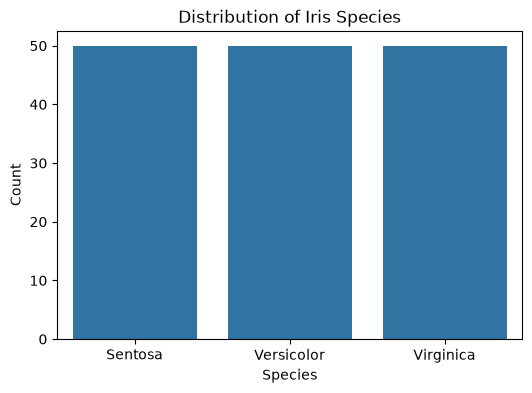

In [7]:
plt.figure(figsize=(6,4))

sns.countplot(data=df,x="Species")

plt.title("Distribution of Iris Species")
plt.xlabel("Species")
plt.ylabel("Count")

plt.show()

## Data Visualization

Visualizing the data helps us understand the realationships between different flower measurements and identify which features seperate the species most effectively.

<function matplotlib.pyplot.show(close=None, block=None)>

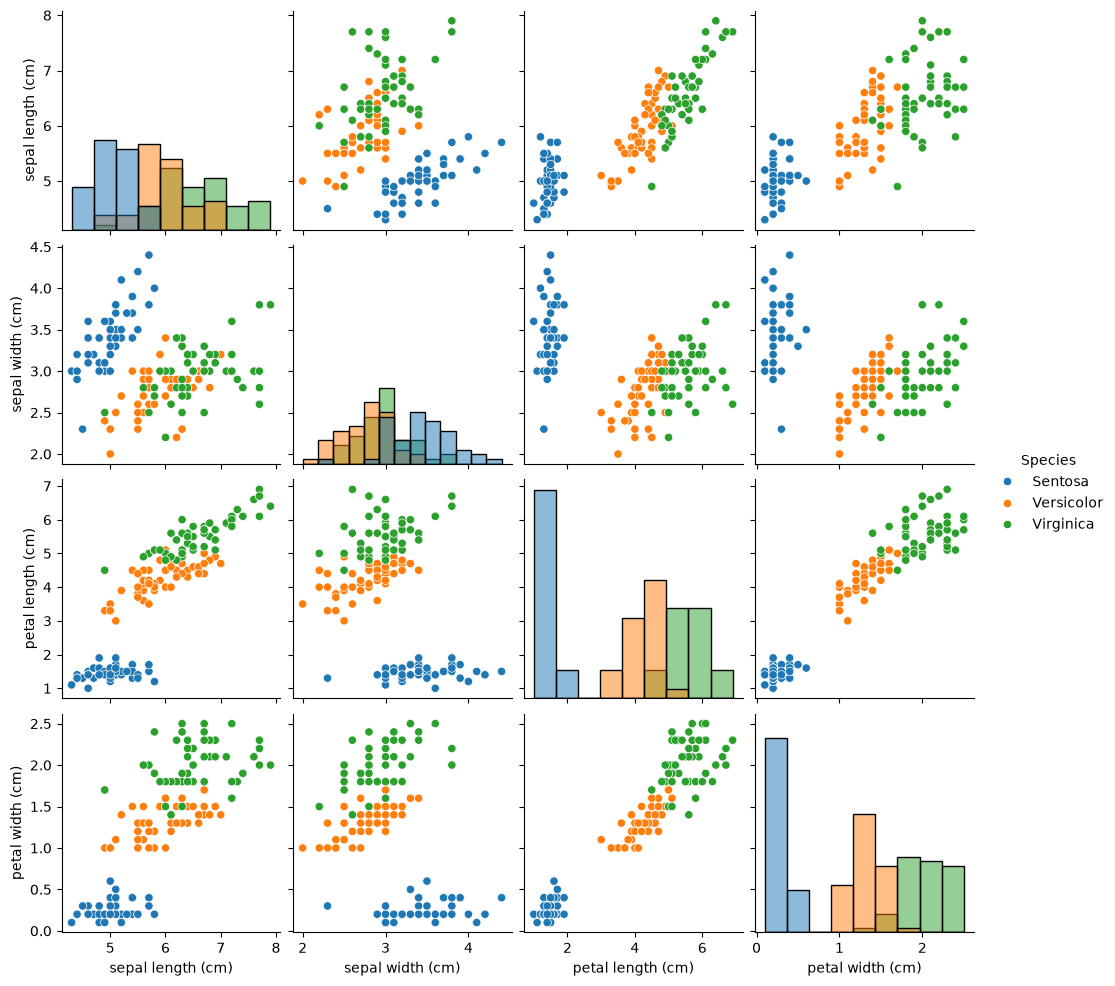

In [9]:
sns.pairplot(df,hue="Species", diag_kind= "hist")
plt.show

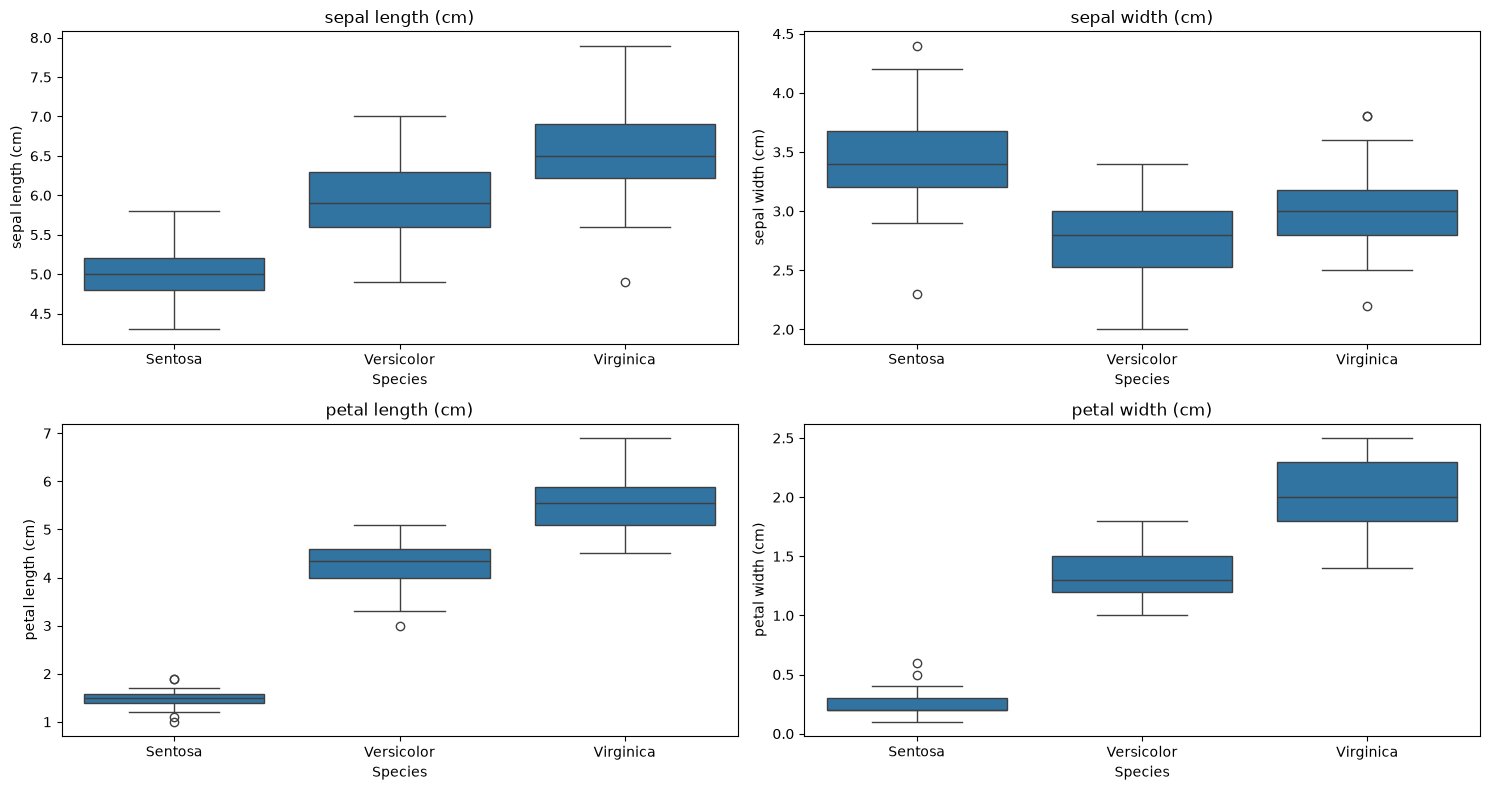

In [10]:
features = df.columns[:-1]

plt.figure(figsize=(15,8))

for i, feature in enumerate(features):
    plt.subplot(2,2,i+1)
    sns.boxplot(data=df, x="Species", y=feature)
    plt.title(feature)

plt.tight_layout()
plt.show()

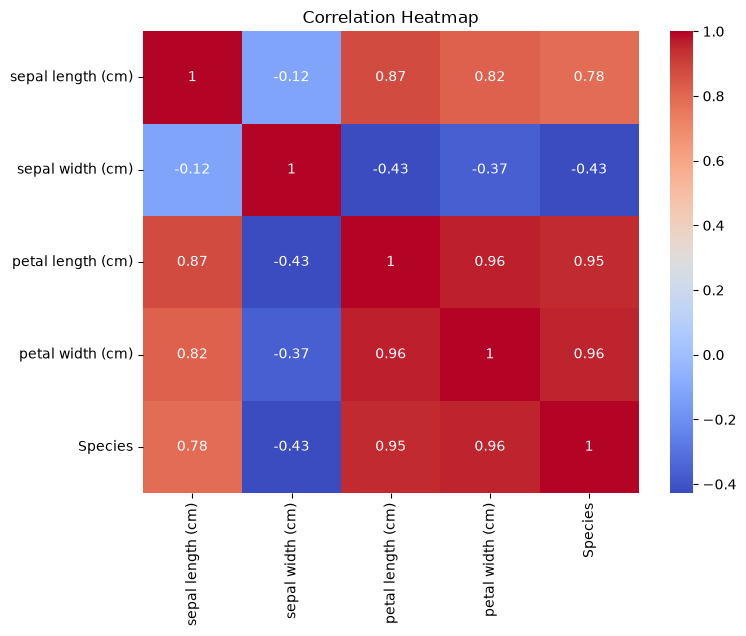

In [12]:
plt.figure(figsize=(8,6))

numeric_df= df.copy()
numeric_df["Species"]= numeric_df["Species"].astype("category").cat.codes

sns.heatmap(numeric_df.corr(), annot= True, cmap="coolwarm")

plt.title("Correlation Heatmap")
plt.show()

## Feature Selection Discussion

From the pairplot and box plots, petal length and petal width appear to be the most discriminative features. These features clearly separate the three iris species with minimal overlap. Sepal length provides moderate separation, while sepal width shows the greatest overlap among species.

Therefore, petal measurements are expected to contribute most to the classification performance.

## Data Preparation

The dataset is divided into features (X) and the target variable (y). We then split the data into training and testing sets using an 80:20 ratio.

In [13]:
X= df.drop("Species", axis = 1)

y = df["Species"]

print("Feature shape:", X.shape)
print("Target shape:", y.shape)

Feature shape: (150, 4)
Target shape: (150,)


In [14]:
X_train, X_test, y_train, y_test = train_test_split( X, y, test_size = 0.2, random_state=42, stratify=y)

print("Training Samples:", X_train.shape[0])
print("Testing Samples:", X_test.shape[0])

Training Samples: 120
Testing Samples: 30


## Model Training

We will train four different classification algorithms and compare their performance:

1. Logistic Regression
2. K-Nearest Neighbors (KNN)
3. Decision Tree
4. Random Forest

In [16]:
# Dictionary of models
models = {
    "Logistic Regression": LogisticRegression(),
    "K-Nearest Neighbors": KNeighborsClassifier(),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42)
}

results = {}

for name, model in models.items():

    # Train model
    model.fit(X_train, y_train)

    # Predictions
    predictions = model.predict(X_test)

    # Accuracy
    accuracy = accuracy_score(y_test, predictions)

    results[name] = {
        "Model": model,
        "Accuracy": accuracy,
        "Predictions": predictions
    }

    print(f"{name}: {accuracy:.4f}")

Logistic Regression: 0.9667
K-Nearest Neighbors: 1.0000
Decision Tree: 0.9333
Random Forest: 0.9000


## Model Evaluation

Each model is evaluated using:

- Accuracy Score
- Confusion Matrix
- Classification Report (Precision, Recall, and F1-score)

In [17]:
for name, result in results.items():

    print("=" * 60)
    print(name)
    print("=" * 60)

    print(f"Accuracy: {result['Accuracy']:.4f}\n")

    print("Confusion Matrix:")
    print(confusion_matrix(y_test, result["Predictions"]))

    print("\nClassification Report:")
    print(classification_report(y_test, result["Predictions"]))

Logistic Regression
Accuracy: 0.9667

Confusion Matrix:
[[10  0  0]
 [ 0  9  1]
 [ 0  0 10]]

Classification Report:
              precision    recall  f1-score   support

     Sentosa       1.00      1.00      1.00        10
  Versicolor       1.00      0.90      0.95        10
   Virginica       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30

K-Nearest Neighbors
Accuracy: 1.0000

Confusion Matrix:
[[10  0  0]
 [ 0 10  0]
 [ 0  0 10]]

Classification Report:
              precision    recall  f1-score   support

     Sentosa       1.00      1.00      1.00        10
  Versicolor       1.00      1.00      1.00        10
   Virginica       1.00      1.00      1.00        10

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30

Deci

In [18]:
accuracy_df = pd.DataFrame({
    "Model": list(results.keys()),
    "Accuracy": [results[m]["Accuracy"] for m in results]
})

accuracy_df = accuracy_df.sort_values(
    by="Accuracy",
    ascending=False
)

accuracy_df

,Model,Accuracy
1,K-Nearest Neighbors,1.000000
0,Logistic Regression,0.966667
2,Decision Tree,0.933333
3,Random Forest,0.900000


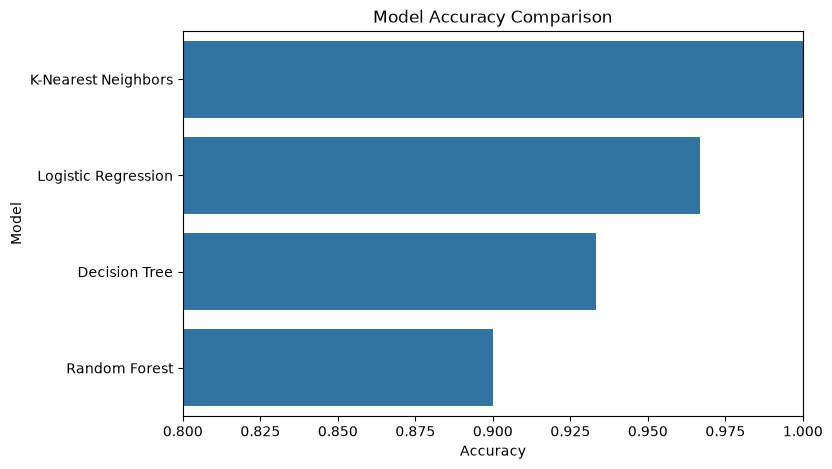

In [19]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=accuracy_df,
    x="Accuracy",
    y="Model"
)

plt.title("Model Accuracy Comparison")
plt.xlim(0.8, 1.0)

plt.show()

## Best Model Selection

After comparing the performance of all the trained models, the model with the highest accuracy was selected as the best-performing model.

The comparison was based on:
- Accuracy Score
- Confusion Matrix
- Classification Report (Precision, Recall, and F1-score)

If multiple models achieved the same accuracy, preference was given to the simpler model because it is computationally efficient and less prone to overfitting.

In [20]:
# Find the best model
best_model = max(results, key=lambda x: results[x]["Accuracy"])

print("Best Model:", best_model)
print("Accuracy:", round(results[best_model]["Accuracy"], 4))

Best Model: K-Nearest Neighbors
Accuracy: 1.0


# Conclusion

In this project, machine learning models were developed to classify iris flowers into three species using their physical measurements.

The project included:
- Loading the Iris dataset
- Exploratory Data Analysis (EDA)
- Data visualization
- Feature analysis
- Model training
- Model evaluation

Among all the trained models, **K-Nearest Neighbors** achieved the highest accuracy and was selected as the final model.

The results demonstrate that machine learning algorithms can accurately classify iris flowers using simple measurements such as petal length and petal width.

In [21]:
plt.savefig("screenshots/pairplot.png", dpi=300, bbox_inches="tight")

<Figure size 640x480 with 0 Axes>